In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\VS CODE\train.csv")

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Get informations of data frame

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.shape

(891, 12)

In [6]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Drop Cabin column

In [8]:
df.drop(columns="Cabin" , inplace= True)

check null values

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

fill age null values with mean

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

Drop the row of embarked

In [12]:
df = df.dropna(subset= "Embarked")

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

checks duplicates values

In [14]:
df.duplicated().sum()

np.int64(0)

check sex unique values

In [15]:
df["Sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

Overall survival rate

In [22]:
survival_rate = df["Survived"].mean() * 100

In [23]:
print(f"Overall survival rate : {survival_rate:.2f}")

Overall survival rate : 38.25


Survival by gender

Survival Rate by Gender
Sex
female    74.038462
male      18.890815
Name: Survived, dtype: float64


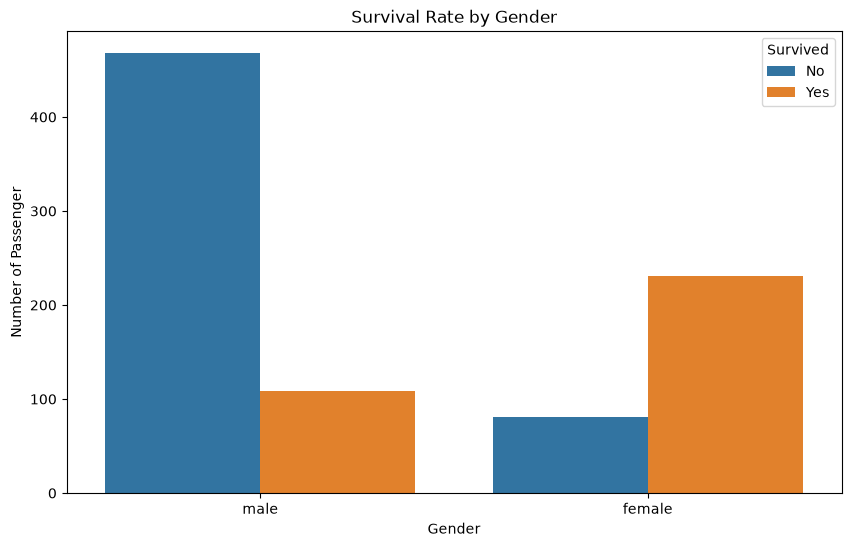

In [27]:
print("Survival Rate by Gender")
print(df.groupby("Sex")["Survived"].mean() * 100)

plt.figure(figsize= (10,6))
sns.countplot(data=df, x = "Sex" , hue = "Survived")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passenger")
plt.legend(title = "Survived" , labels = ["No" , "Yes"])
plt.show()

Survived by Passenger class

Survived Rate by Passenger Class
Pclass
1    62.616822
2    47.282609
3    24.236253
Name: Survived, dtype: float64


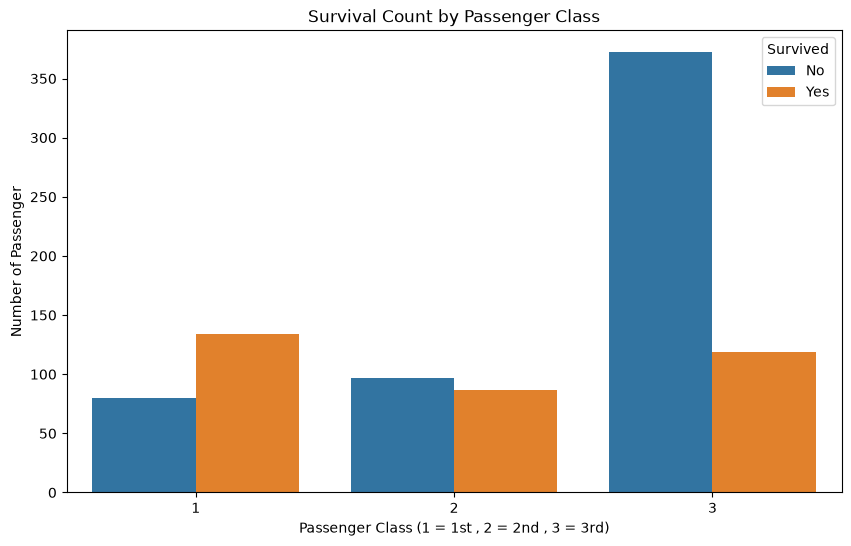

In [28]:
print("Survived Rate by Passenger Class")
print(df.groupby("Pclass")["Survived"].mean() * 100)


plt.figure(figsize= (10,6))
sns.countplot(data = df , x = "Pclass" , hue = "Survived")
plt.title("Survival Count by Passenger Class")
plt.xlabel("Passenger Class (1 = 1st , 2 = 2nd , 3 = 3rd)")
plt.ylabel("Number of Passenger")
plt.legend(title = "Survived" , labels = ["No" , "Yes"])
plt.show()

Survived by Age

Survival Rate by Age Group
AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          39.690722
Senior         19.047619
Name: Survived, dtype: float64


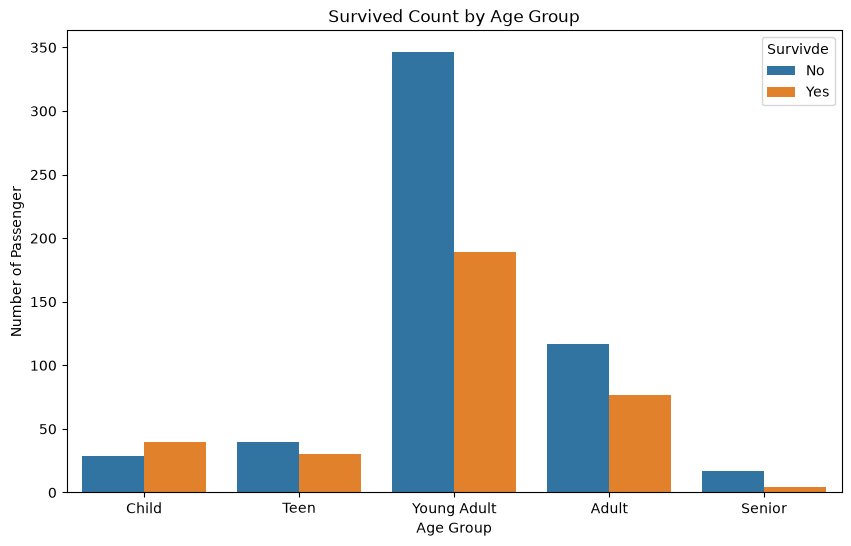

In [29]:
bins = [0,12,18,35,60,80]
labels = ["Child" , "Teen" , "Young Adult" , "Adult" , "Senior"]
df["AgeGroup"] = pd.cut(df["Age"] , bins = bins , labels= labels)

print("Survival Rate by Age Group")
print(df.groupby("AgeGroup" , observed= True)["Survived"].mean() * 100)


plt.figure(figsize = (10,6))
sns.countplot(data = df , x = "AgeGroup" , hue = "Survived")
plt.title("Survived Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passenger")
plt.legend(title = "Survivde" , labels = ["No" , "Yes"])
plt.show()

Age Distribution Of Passenger

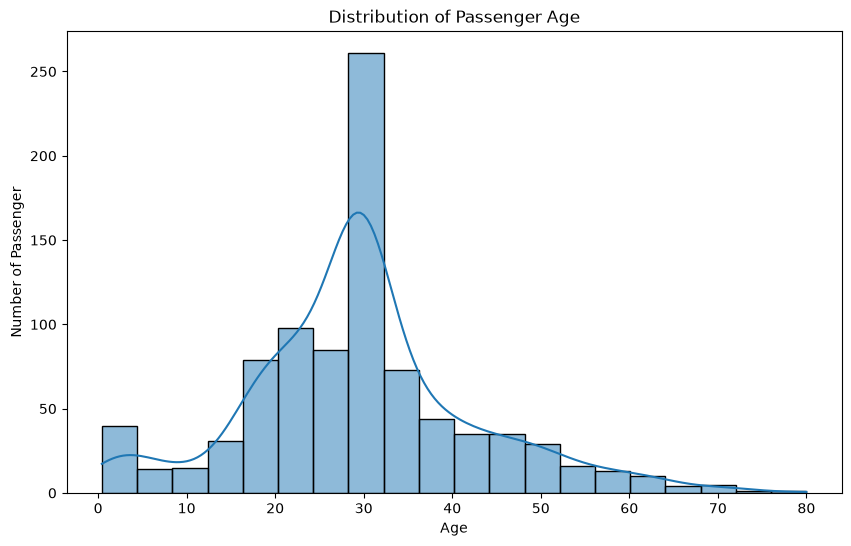

In [30]:
plt.figure(figsize = (10,6))
sns.histplot(x = df["Age"] , bins = 20 , kde = True)
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passenger")
plt.show()

Survival by Class and Gender Together

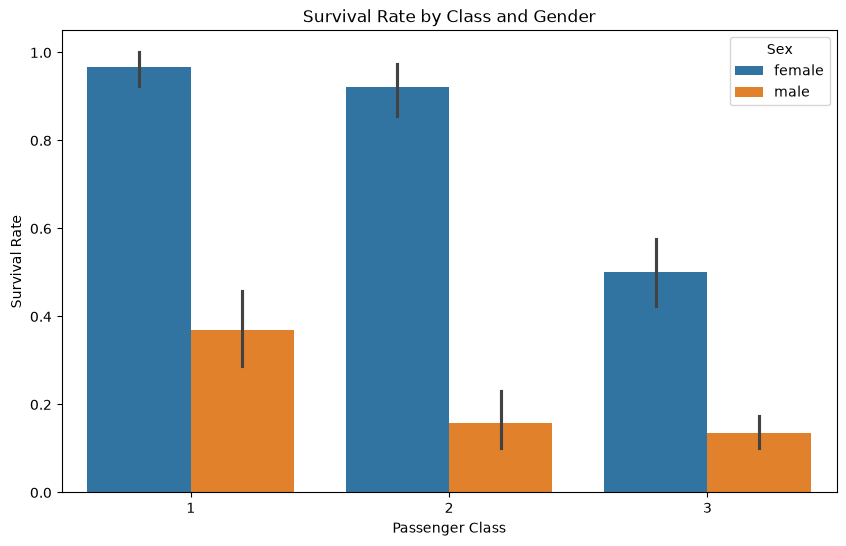

In [31]:
plt.figure(figsize = (10,6))
sns.barplot(data = df , x = "Pclass" , y = "Survived" , hue = "Sex")
plt.title("Survival Rate by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

Conclusions

In [37]:
print("----- Summary of Findings -----".center(50))
print("\n1. Females had a much higher survival rate by males.")
print("2. 1st Class passenger survived more than 2nd and 3rd class.")
print("3. Children has a relatively better survival rate than adults.")
print("\nThis matches the 'woman and children first' policy followed during disaster.")

         ----- Summary of Findings -----          

1. Females had a much higher survival rate by males.
2. 1st Class passenger survived more than 2nd and 3rd class.
3. Children has a relatively better survival rate than adults.

This matches the 'woman and children first' policy followed during disaster.
